# SWAP-Stress: SMAP L3 Soil Moisture for Water Potential Modeling

This notebook demonstrates the **SMAP Enhanced L3** (SPL3SMP_E) daily soil moisture
data used as the primary dynamic input in SWAP-Stress.

The SMAP radiometer measures L-band (1.4 GHz) microwave brightness temperature,
which is sensitive to moisture in the top ~5 cm of soil. We use the 9 km Enhanced
product on the EASE-Grid2, converted to daily CONUS GeoTIFFs.

This notebook covers:
1. SMAP product family overview
2. Why L3, not L4?
3. Single-day spatial coverage map
4. Temporal coverage summary (2015–2026)
5. Multi-year summer composites (mean and standard deviation)

In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception:
    rasterio = None

try:
    import geopandas as gpd
except Exception:
    gpd = None

# -----------------------------
# Config
# -----------------------------
DATA_ROOT = os.environ.get("SWAPSTRESS_DATA_ROOT", "/nas/soils")
DATA_ROOT = str(Path(DATA_ROOT).expanduser())

SMAP_TIF_DIR = os.path.join(DATA_ROOT, "smap", "SPL3SMP_E", "daily_tif")
US_STATES_SHP = "/nas/boundaries/us_states_tiger_wgs.shp"

OUT_DIR = Path("notebooks/_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("SMAP_TIF_DIR:", SMAP_TIF_DIR)
print("TIF count:", len([f for f in os.listdir(SMAP_TIF_DIR) if f.endswith(".tif")]))

DATA_ROOT: /nas/soils
SMAP_TIF_DIR: /nas/soils/smap/SPL3SMP_E/daily_tif
TIF count: 3301


## 1) SMAP Product Family Overview

NASA's Soil Moisture Active Passive (SMAP) mission (launched Jan 2015) provides
multiple soil moisture products at different processing levels.

| Product | Level | Resolution | Temporal | Description |
|---------|-------|-----------|----------|-------------|
| SPL1CTB | L1C | 36 km | Half-orbit | Calibrated brightness temperature (Tb) |
| SPL2SMP | L2 | 36 km | Half-orbit | Soil moisture from Tb (single-channel algorithm) |
| SPL2SMP_E | L2 | 9 km | Half-orbit | Enhanced 9 km via Backus-Gilbert interpolation of Tb |
| **SPL3SMP_E** | **L3** | **9 km** | **Daily** | **Daily composite of L2 Enhanced (our choice)** |
| SPL3FTP | L3 | 9 km | Daily | Freeze/thaw state |
| SPL4SMGP | L4 | 9 km | 3-hourly | Assimilated soil moisture from NASA Catchment LSM |
| SPL4SMAU | L4 | 9 km | 3-hourly | Analysis update (observation minus forecast) |

We use **SPL3SMP_E** — the daily Enhanced L3 product at 9 km resolution.

## 2) SMAP Product Choice

The L4 product (SPL4SMGP) assimilates brightness temperature into NASA's Catchment
Land Surface Model, which uses its own pedotransfer-derived soil hydraulic
parameters. We want to build our own PTF, so we will use a lower-level product.

As far as I can tell, both L2 and L3 both use soil texture to derive their dielectric mixing model. Daily 9 km.


In [2]:
assert rasterio is not None, "rasterio is required"

# Load a mid-summer reference file
ref_file = os.path.join(SMAP_TIF_DIR, "smap_sm_20200725.tif")
assert os.path.exists(ref_file), f"Missing: {ref_file}"

with rasterio.open(ref_file) as src:
    print(f"File: {os.path.basename(ref_file)}")
    print(f"Shape: {src.width} x {src.height} (cols x rows)")
    print(f"CRS: {src.crs}")
    print(f"Bounds: {src.bounds}")
    print(f"Pixel size: {src.transform.a:.3f} m")
    print(f"Band description: {src.descriptions[0]}")

    data = src.read(1)
    valid = data[~np.isnan(data)]
    print(
        f"\nValid pixels: {len(valid):,} / {data.size:,} ({100 * len(valid) / data.size:.1f}%)"
    )
    print(f"Value range: {valid.min():.4f} \u2013 {valid.max():.4f} m\u00b3/m\u00b3")
    print(f"Mean: {valid.mean():.4f}, Median: {np.median(valid):.4f}")

File: smap_sm_20200725.tif
Shape: 634 x 295 (cols x rows)
CRS: EPSG:6933
Bounds: BoundingBox(left=-12061785.926385494, bottom=2963650.1641380335, right=-6350678.92315293, top=5621026.451131104)
Pixel size: 9008.055 m
Band description: soil_moisture_am

Valid pixels: 59,297 / 187,030 (31.7%)
Value range: 0.0200 – 0.6844 m³/m³
Mean: 0.2200, Median: 0.2002


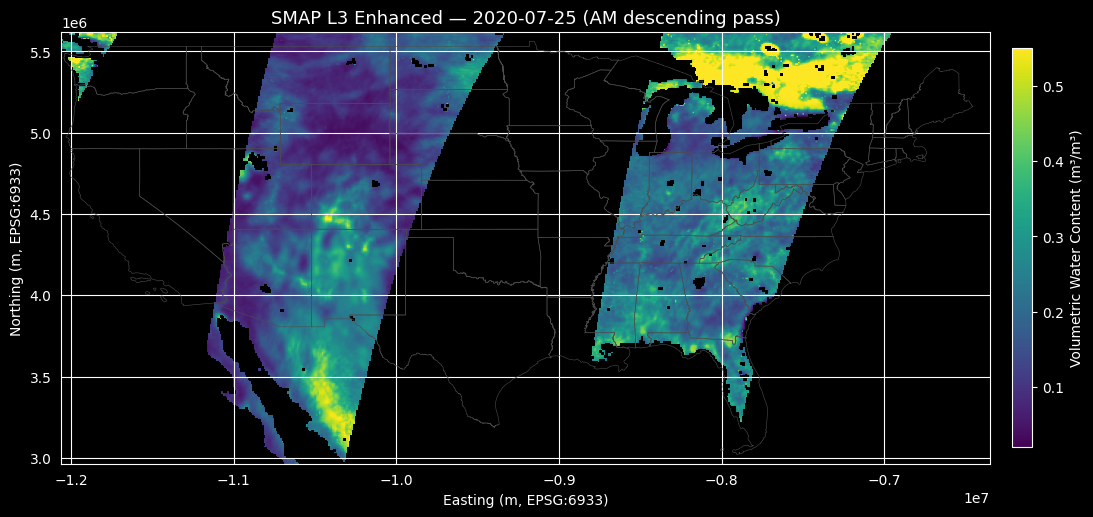

Saved: notebooks/_outputs/smap_l3_single_day.png


In [3]:
# Load US state boundaries reprojected to EASE-Grid2
states = None
if gpd is not None and os.path.exists(US_STATES_SHP):
    states = gpd.read_file(US_STATES_SHP).to_crs(epsg=6933)

with rasterio.open(ref_file) as src:
    data = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    data,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=0.02,
    vmax=0.55,
)

if states is not None:
    states.boundary.plot(ax=ax, color="0.3", linewidth=0.4)

# Clip to raster bounds (already a CONUS subset)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("Volumetric Water Content (m³/m³)")

ax.set_title("SMAP L3 Enhanced — 2020-07-25 (AM descending pass)", fontsize=13)
ax.set_xlabel("Easting (m, EPSG:6933)")
ax.set_ylabel("Northing (m, EPSG:6933)")

out = OUT_DIR / "smap_l3_single_day.png"
fig.tight_layout()
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

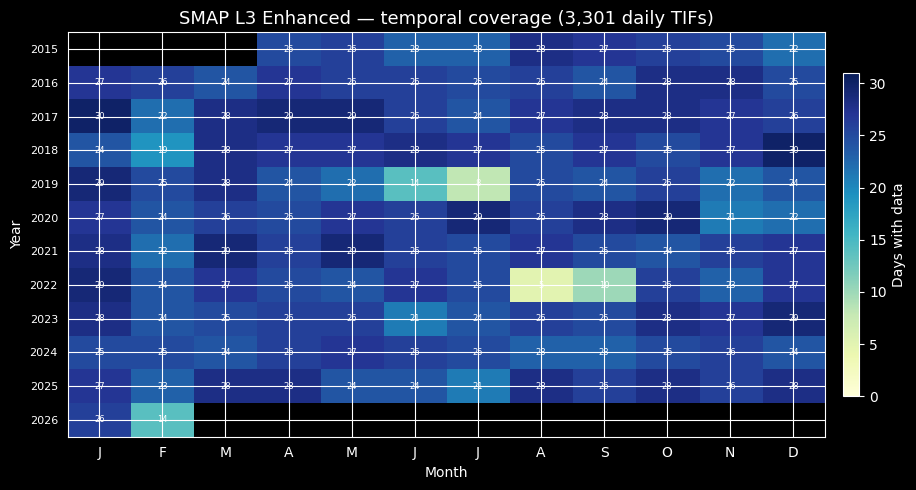

Saved: notebooks/_outputs/smap_l3_temporal_coverage.png


In [4]:
from collections import defaultdict

# Scan all daily TIF filenames
files = sorted(f for f in os.listdir(SMAP_TIF_DIR) if f.endswith(".tif"))
dates = []
for f in files:
    m = re.search(r"(\d{8})", f)
    if m:
        d = m.group(1)
        dates.append((int(d[:4]), int(d[4:6])))

# Count files per year-month
ym_counts = defaultdict(int)
for y, mo in dates:
    ym_counts[(y, mo)] += 1

years = sorted(set(y for y, mo in ym_counts))
months = list(range(1, 13))

# Build heatmap array
grid = np.full((len(years), 12), np.nan)
for i, y in enumerate(years):
    for j, mo in enumerate(months):
        if (y, mo) in ym_counts:
            grid[i, j] = ym_counts[(y, mo)]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(grid, aspect="auto", cmap="YlGnBu", vmin=0, vmax=31)

ax.set_yticks(range(len(years)))
ax.set_yticklabels(years, fontsize=8)
ax.set_xticks(range(12))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])

# Annotate counts
for i in range(len(years)):
    for j in range(12):
        if not np.isnan(grid[i, j]):
            ax.text(j, i, f"{int(grid[i, j])}", ha="center", va="center", fontsize=6)

cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label("Days with data")

ax.set_title(
    f"SMAP L3 Enhanced \u2014 temporal coverage ({len(files):,} daily TIFs)",
    fontsize=13,
)
ax.set_xlabel("Month")
ax.set_ylabel("Year")

out = OUT_DIR / "smap_l3_temporal_coverage.png"
fig.tight_layout()
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

Summer files found: 450, sampling 100


/tmp/ipykernel_1936699/2803604164.py:28: RuntimeWarning: Mean of empty slice
  mean_sm = np.nanmean(stack, axis=0)
/home/dgketchum/miniconda/envs/swap/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Mean SM range: 0.0275 – 0.7554
Std SM range: 0.0000 – 0.2443


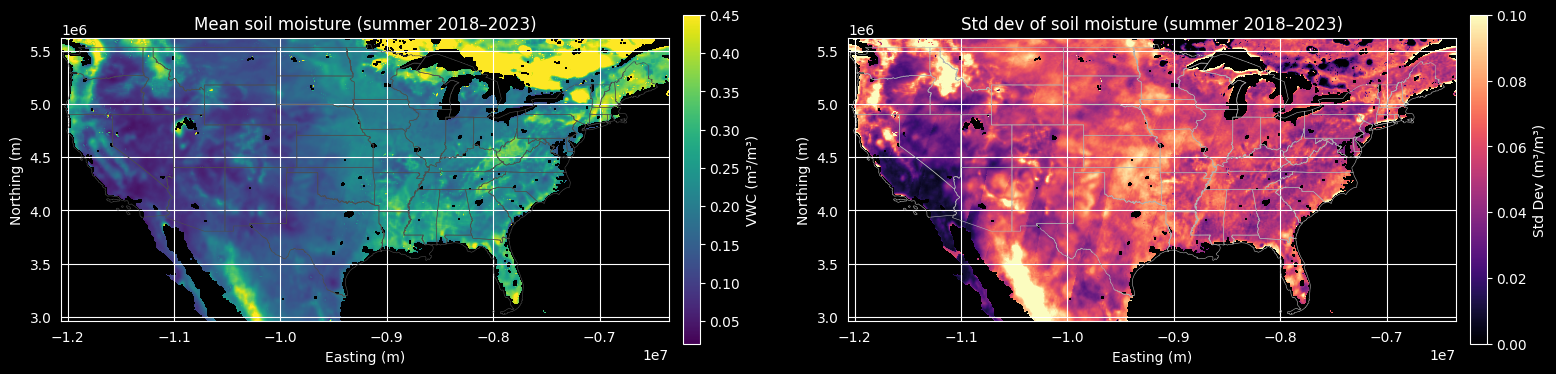

Saved: notebooks/_outputs/smap_l3_summer_composite.png


In [5]:
import datetime as dt

# Sample ~100 summer days (DOY 150-250) from 2018-2023
summer_files = []
for f in files:
    m = re.search(r"(\d{8})", f)
    if m:
        d = dt.datetime.strptime(m.group(1), "%Y%m%d")
        doy = d.timetuple().tm_yday
        if 2018 <= d.year <= 2023 and 150 <= doy <= 250:
            summer_files.append(f)

# Subsample to ~100 files evenly
step = max(1, len(summer_files) // 100)
sample = summer_files[::step][:100]
print(f"Summer files found: {len(summer_files)}, sampling {len(sample)}")

# Read and stack
with rasterio.open(os.path.join(SMAP_TIF_DIR, sample[0])) as src:
    shape = (src.height, src.width)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

stack = np.full((len(sample), *shape), np.nan, dtype=np.float32)
for i, f in enumerate(sample):
    with rasterio.open(os.path.join(SMAP_TIF_DIR, f)) as src:
        stack[i] = src.read(1)

mean_sm = np.nanmean(stack, axis=0)
std_sm = np.nanstd(stack, axis=0)

# Mask pixels with too few valid obs
obs_count = np.sum(~np.isnan(stack), axis=0)
mask = obs_count < 10
mean_sm[mask] = np.nan
std_sm[mask] = np.nan

print(f"Mean SM range: {np.nanmin(mean_sm):.4f} \u2013 {np.nanmax(mean_sm):.4f}")
print(f"Std SM range: {np.nanmin(std_sm):.4f} \u2013 {np.nanmax(std_sm):.4f}")

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

im1 = ax1.imshow(
    mean_sm, extent=extent, origin="upper", cmap="viridis", vmin=0.02, vmax=0.45
)
if states is not None:
    states.boundary.plot(ax=ax1, color="0.3", linewidth=0.4)
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.7, pad=0.02)
cb1.set_label("VWC (m\u00b3/m\u00b3)")
ax1.set_title("Mean soil moisture (summer 2018\u20132023)")

im2 = ax2.imshow(std_sm, extent=extent, origin="upper", cmap="magma", vmin=0, vmax=0.10)
if states is not None:
    states.boundary.plot(ax=ax2, color="0.7", linewidth=0.4)
cb2 = fig.colorbar(im2, ax=ax2, shrink=0.7, pad=0.02)
cb2.set_label("Std Dev (m\u00b3/m\u00b3)")
ax2.set_title("Std dev of soil moisture (summer 2018\u20132023)")

# Clip to raster bounds (already a CONUS subset)
for a in (ax1, ax2):
    a.set_xlim(extent[0], extent[1])
    a.set_ylim(extent[2], extent[3])
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")

out = OUT_DIR / "smap_l3_summer_composite.png"
fig.tight_layout()
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

## 6) Gap-fill Coverage

SMAP L3 covers only ~32 % of CONUS pixels on any given day (one ascending or
descending pass).  `map.inference.gapfill_conus.run_gapfill()` performs
pixel-wise linear interpolation along the time axis to fill all spatial and
temporal gaps, yielding 100 % CONUS coverage every day.

Here we show the valid-pixel count time series (raw vs gap-filled) and a
side-by-side map for a single day.


In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception:
    rasterio = None

from map.inference.gapfill_conus import discover_source_rasters

DATA_ROOT = os.environ.get("SWAPSTRESS_DATA_ROOT", "/nas/soils")
DATA_ROOT = str(Path(DATA_ROOT).expanduser())

SMAP_DIR = os.path.join(DATA_ROOT, "smap", "SPL3SMP_E", "daily_tif")
SMAP_GF  = SMAP_DIR + "_gapfilled"

assert rasterio is not None, "rasterio is required"

raw_files = discover_source_rasters(SMAP_DIR, prefix="smap_sm")
gf_files  = discover_source_rasters(SMAP_GF,  prefix="smap_sm")

print(f"Raw SMAP files:       {len(raw_files):,}")
print(f"Gap-filled SMAP:      {len(gf_files):,}")

raw_dates = sorted(raw_files)
gf_dates  = sorted(gf_files)

# Count valid pixels per day
raw_valid = []
for d in raw_dates:
    with rasterio.open(raw_files[d]) as src:
        arr = src.read(1)
    raw_valid.append(int(np.sum(~np.isnan(arr))))

gf_valid = []
for d in gf_dates:
    with rasterio.open(gf_files[d]) as src:
        arr = src.read(1)
    gf_valid.append(int(np.sum(~np.isnan(arr))))

print(f"\nRaw  — median valid px/day: {np.median(raw_valid):,.0f}")
print(f"GF   — median valid px/day: {np.median(gf_valid):,.0f}")


In [ ]:
from datetime import date

# --- Bar chart: raw vs gap-filled valid-pixel count per day ---
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar([d.toordinal() for d in raw_dates], raw_valid,
        width=1, color="steelblue", alpha=0.8, label="Raw")
ax.bar([d.toordinal() for d in gf_dates], gf_valid,
        width=1, color="tomato", alpha=0.4, label="Gap-filled")

ax.set_xlabel("Date")
ax.set_ylabel("Valid pixels")
ax.set_title("SMAP L3 valid-pixel count per day: raw vs gap-filled")
ax.legend()

year_ticks = [d for d in raw_dates if d.month == 1 and d.day == 1]
ax.set_xticks([d.toordinal() for d in year_ticks])
ax.set_xticklabels([str(d.year) for d in year_ticks], rotation=45)
fig.tight_layout()
plt.show()

# --- Side-by-side map: one raw day vs gap-filled ---
show_date = date(2024, 6, 15)
assert show_date in raw_files, f"{show_date} not in raw SMAP"
assert show_date in gf_files,  f"{show_date} not in gap-filled SMAP"

with rasterio.open(raw_files[show_date]) as src:
    raw_arr = src.read(1)
    extent  = [src.bounds.left, src.bounds.right,
                 src.bounds.bottom, src.bounds.top]

with rasterio.open(gf_files[show_date]) as src:
    gf_arr = src.read(1)

valid_all = np.concatenate([raw_arr[~np.isnan(raw_arr)],
                              gf_arr[~np.isnan(gf_arr)]])
vmin, vmax = np.percentile(valid_all, [2, 98])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for ax, arr, title in [
    (ax1, raw_arr,
     f"Raw SMAP — {show_date} ({np.sum(~np.isnan(raw_arr)):,} valid px)"),
    (ax2, gf_arr,
     f"Gap-filled SMAP — {show_date} ({np.sum(~np.isnan(gf_arr)):,} valid px)"),
]:
    im = ax.imshow(arr, extent=extent, origin="upper",
                   cmap="viridis", vmin=vmin, vmax=vmax)
    if states is not None:
        states.boundary.plot(ax=ax, color="0.3", linewidth=0.3)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label="VWC (m³/m³)")
    ax.set_title(title, fontsize=11)
    ax.tick_params(labelsize=7)

fig.tight_layout()
plt.show()
print("Reference: map.inference.gapfill_conus.run_gapfill()")
